In [39]:
import pandas as pd

df = pd.read_csv("../data/titanic.csv") # Load the titanic dataset

df.shape # Show the number of rows and columns of a dataset

(891, 12)

Showing the first few rows of the dataset

In [21]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [24]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [28]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [29]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
(df.isnull().sum())/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

The dataset was checked for duplicate records using `df.duplicated().sum()`.

Result:
- No duplicate rows were found in the dataset.

Therefore, no duplicate removal was required.

In [ ]:
df.duplicated().sum()
# df = df.drop_duplicates()

np.int64(0)

In [7]:
missing = df.isnull().sum()
missing_percentage = (missing/len(df))*100

pd.DataFrame({
    "Missing values":missing,
    "Percentage":missing_percentage
}).sort_values("Missing values",ascending=False)

,Missing values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [8]:
df["Cabin"].isnull().sum()

np.int64(687)

## Missing Value Analysis

Three columns contain missing values:

| Column | Missing Values | Percentage |
|---------|---------|---------|
| Cabin | 687 | 77.10% |
| Age | 177 | 19.87% |
| Embarked | 2 | 0.22% |

Observations:

- Cabin contains a very large number of missing values and may be considered for removal.
- Age contains a moderate number of missing values and should be imputed.
- Embarked contains only two missing values and can be handled easily through imputation or row removal.

In [10]:
df[df["Cabin"].isnull()].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [11]:
df[df["Age"].isnull()].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


In [12]:
df[df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Analyzing the above 2 rows further instead using simple imputation at first (Mode/Median imputation)

In [13]:
df[df["Cabin"]=="B28"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [14]:
df[df["Ticket"]=="113572"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [15]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [18]:
df.groupby("Embarked")["Fare"].mean()

Embarked
C    59.954144
Q    13.276030
S    27.243651
Name: Fare, dtype: float64

## Embarked Missing Value Analysis

The `Embarked` column contained 2 missing values.

Investigation showed that both passengers:

- Traveled in First Class (Pclass = 1)
- Had the same ticket number (113572)
- Occupied the same cabin (B28)
- Paid a fare of 80.0

Average fare analysis by embarkation port showed:

| Embarked | Average Fare |
|-----------|-------------:|
| C | 59.95 |
| Q | 13.28 |
| S | 27.24 |

Since the fare of 80.0 is most consistent with passengers embarking from Cherbourg (`C`), the missing values were imputed with `C`.

This approach was chosen instead of simple mode imputation because it uses contextual information from the dataset.

In [19]:
df.loc[df["Embarked"].isnull(),"Embarked"]="C"
df["Embarked"].isnull().sum()

np.int64(0)

## Cabin Feature Analysis and Treatment

The `Cabin` column was identified as having a significant amount of missing data.

### Missing Value Statistics

- Total Records: 891
- Missing Cabin Values: 687
- Missing Percentage: 77.10%

### Investigation

Analysis of the `Cabin` column revealed:

- A very high percentage of missing values.
- Numerous unique cabin identifiers such as `B28`, `C85`, `E46`, and `G6`.
- Most cabin values occurred only a few times.
- Direct imputation using mode, mean, or median was not appropriate because cabin numbers represent categorical location information rather than numerical measurements.

### Feature Engineering

Although the full cabin identifier contained too many missing values, the first character of the cabin value represents the passenger's deck.

Examples:

| Cabin | Deck |
|---------|---------|
| B28 | B |
| C85 | C |
| E46 | E |
| G6 | G |

To preserve potentially useful information, a new feature named `Deck` was created by extracting the first character from the `Cabin` column.

### Final Decision

After extracting the deck information:

- The original `Cabin` column was removed.
- The new `Deck` feature was retained for future analysis and modeling.

This approach preserves meaningful information while eliminating a feature with excessive missing values.

In [21]:
cabin_missing = df["Cabin"].isnull().sum()
cabin_miss_percentage = (cabin_missing/len(df))*100

print("Missing values :",cabin_missing)
print("Missing Percentage: ",cabin_miss_percentage)

Missing values : 687
Missing Percentage:  77.10437710437711


In [22]:
df["Cabin"].value_counts().head()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
Name: count, dtype: int64

In [23]:
df["Deck"]= df["Cabin"].str[0]
df["Deck"].value_counts(dropna=False)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [24]:
df.drop(columns=["Cabin"],inplace=True)

## Age Feature Analysis and Missing Value Investigation

The `Age` column contains missing values and is an important feature for predicting passenger survival.

### Missing Value Statistics

- Total Records: 891
- Missing Age Values: 177
- Missing Percentage: 19.87%

### Importance of the Feature

Age is considered a significant variable because survival rates on the Titanic varied across different age groups.

Examples:

- Children were often prioritized during evacuation.
- Adults and elderly passengers may have experienced different survival outcomes.
- Age can influence travel patterns and passenger characteristics.

Therefore, removing the `Age` column would result in the loss of potentially valuable information.

### Investigation Strategy

Before selecting an imputation method, the distribution of the `Age` feature must be analyzed.

The following questions need to be answered:

1. Is the distribution approximately symmetric?
2. Is the distribution skewed?
3. Are there significant outliers?
4. Which measure of central tendency best represents the data?

### Imputation Decision Criteria

| Distribution Type | Preferred Imputation Method |
|-------------------|----------------------------|
| Approximately Normal | Mean |
| Skewed Distribution | Median |
| Categorical Data | Mode |

To determine the most appropriate imputation technique, the distribution and skewness of the `Age` feature will be examined using statistical measures and visualizations.

### Next Steps

The following analyses will be performed:

- Summary statistics of Age
- Distribution visualization
- Skewness calculation
- Outlier investigation

The results of these analyses will guide the selection of an appropriate imputation strategy.

In [25]:
df["Age"].skew()

np.float64(0.38910778230082704)

In [27]:
df.groupby("Pclass")["Age"].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [28]:
df.groupby("Sex")["Age"].median()

Sex
female    27.0
male      29.0
Name: Age, dtype: float64

In [40]:
df["Age"] = df.groupby(["Pclass","Sex"])["Age"].transform(lambda x: x.fillna(x.median()))

## Age Imputation Strategy Selection

The Age column contains 177 missing values (19.87% of the dataset).

### Distribution Analysis

- Skewness: 0.389
- The distribution is approximately symmetric.
- Mean imputation would normally be considered appropriate.

### Group Analysis

Median age by passenger class:

| Pclass | Median Age |
|---------|-----------|
| 1 | 37 |
| 2 | 29 |
| 3 | 24 |

The substantial difference between passenger classes indicates that age is associated with passenger class.

### Decision

Instead of using a single global mean or median for all passengers, a group-wise median imputation approach will be used.

This approach preserves age differences between passenger classes and produces more realistic estimates for missing values.

### Selected Method

Group-wise median imputation based on passenger class.

Benefits:

- Reduces imputation bias
- Preserves class-specific age characteristics
- More representative than global mean imputation

# Outlier Detection and Treatment

## Objective

Outliers are observations that differ significantly from the majority of the data.

These extreme values may arise due to:

- Data entry errors
- Measurement errors
- Natural variability
- Rare but valid observations

Outliers can influence:

- Mean
- Standard Deviation
- Correlation
- Regression Models
- Distance-based Algorithms

Therefore, identifying and evaluating outliers is an important step in data preprocessing.

## Outlier Detection Techniques

The following methods will be explored:

1. Statistical Summary Analysis
2. Boxplot Visualization
3. Interquartile Range (IQR) Method
4. Z-Score Method
5. Percentile-Based Detection

## Outlier Treatment Techniques

The following treatments will be evaluated:

1. No Treatment
2. Row Removal
3. Capping (Winsorization)
4. Flooring
5. Transformation (Log Transformation)

The goal is to determine whether detected outliers represent errors or legitimate observations before deciding on an appropriate treatment strategy.

In [74]:
df.select_dtypes(include = ["int64", "float64"]).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [75]:
df["Age"].apply(type).value_counts()

Age
<class 'float'>    891
Name: count, dtype: int64

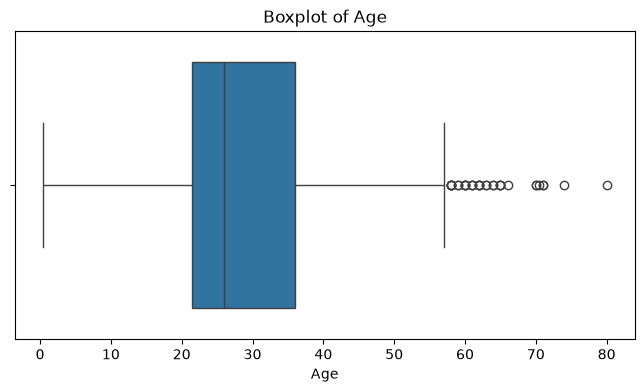

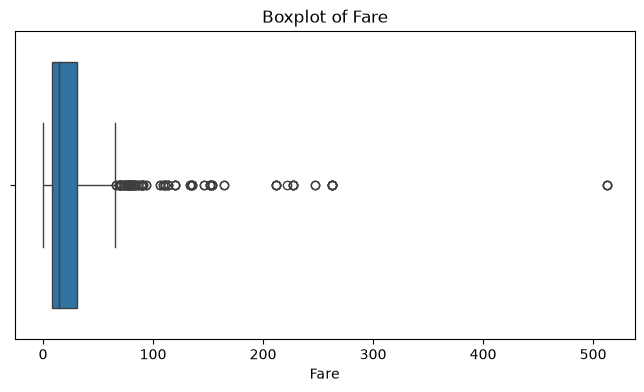

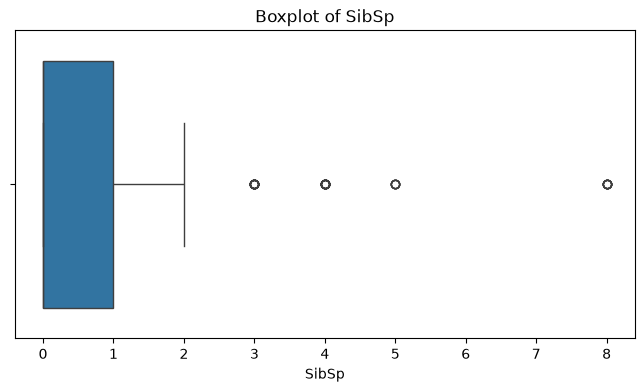

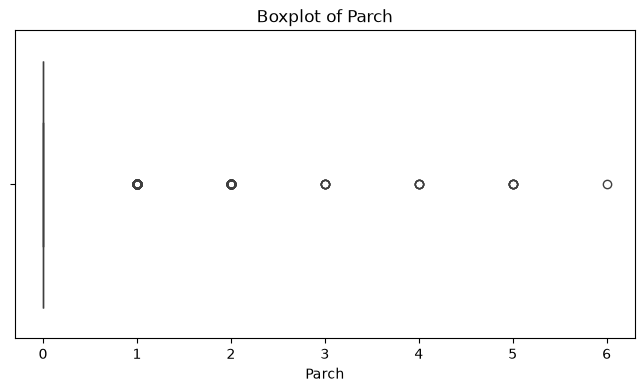

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Quantifying the outliers

In [77]:
def detect_outliers_iqr(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    outliers = df[
        (df[column]<lower_bound)| (df[column]>upper_bound)
    ]
    
    print(f"Column: {column}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

In [78]:
detect_outliers_iqr(df, "Age")

Column: Age
Lower Bound: -0.25
Upper Bound: 57.75
Number of Outliers: 33


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
94,95,0,3,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.2500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S
195,196,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.5208,B80,C
232,233,0,2,"Sjostedt, Mr. Ernst Adolf",male,59.0,0,0,237442,13.5000,NaN,S
252,253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,C87,S


In [79]:
detect_outliers_iqr(df, "Fare")

Column: Fare
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Outliers: 116


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,35.0,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,25.0,8,2,CA. 2343,69.5500,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,35.0,1,0,17453,89.1042,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,21.5,8,2,CA. 2343,69.5500,NaN,S


In [80]:
detect_outliers_iqr(df, "SibSp")

Column: SibSp
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 46


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9000,NaN,S
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.0,4,2,3101281,7.9250,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9000,NaN,S
85,86,1,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,3,0,3101278,15.8500,NaN,S


In [81]:
detect_outliers_iqr(df, "Parch")

Column: Parch
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers: 213


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


Handling outliers of Age Column

Since the ages deteced as outliers are possible to happen it's recommended to keep as it is thus they are valid outliers

In [82]:
age_outliers = df[df["Age"] > 57.75]

age_outliers[["Name", "Age", "Pclass", "Sex"]].head(10)

,Name,Age,Pclass,Sex
11,"Bonnell, Miss. Elizabeth",58.0,1,female
33,"Wheadon, Mr. Edward H",66.0,2,male
54,"Ostby, Mr. Engelhart Cornelius",65.0,1,male
94,"Coxon, Mr. Daniel",59.0,3,male
96,"Goldschmidt, Mr. George B",71.0,1,male
116,"Connors, Mr. Patrick",70.5,3,male
170,"Van der hoef, Mr. Wyckoff",61.0,1,male
195,"Lurette, Miss. Elise",58.0,1,female
232,"Sjostedt, Mr. Ernst Adolf",59.0,2,male
252,"Stead, Mr. William Thomas",62.0,1,male


Learning all the outlier treatments below 

1. Remove outliers

In [83]:
fare_removed = df[
    (df["Fare"] >= -26.724) &
    (df["Fare"] <= 65.6344)
]

In [84]:
print(df.shape)
print(fare_removed.shape)

(891, 12)
(775, 12)


2. Capping (Winzorization)

fare_capped = df.copy()

fare_capped["Fare"] = fare_capped["Fare"].clip(
    lower=-26.724,
    upper=65.6344
)

In [87]:
import numpy as np

fare_log = df.copy()

fare_log["Fare"] = np.log1p(fare_log["Fare"])

fare_log.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,NaN,S
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,2.246893,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,3.967694,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,3.094446,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,2.495954,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,3.436268,NaN,C


In [88]:
print("Original Skewness:", df["Fare"].skew())
print("Log Skewness:", fare_log["Fare"].skew())

Original Skewness: 4.787316519674893
Log Skewness: 0.3949280095189306


## Fare Outlier Analysis

The Fare feature was analyzed using the Interquartile Range (IQR) method.

Results:

- Lower Bound: -26.724
- Upper Bound: 65.6344
- Number of Outliers: 116

### Observation

The Fare distribution exhibits significant right skewness with several high-value observations.

Investigation revealed that these values correspond to legitimate first-class passenger fares rather than data-entry errors.

### Conclusion

The detected outliers are considered valid observations. Therefore:

- Outlier removal is not recommended.
- Alternative approaches such as capping and log transformation may be explored for modeling purposes.
- The original Fare values will be retained to preserve information.